In [2]:
# ============================================================
# ATTENTION MECHANISM USING NLP
# PART-1 : DATA LOADING & PREPROCESSING
# CPU FRIENDLY
# ============================================================

import numpy as np
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

VOCAB_SIZE = 5000
MAX_LENGTH = 100

# Small dataset for slow CPU
TRAIN_SIZE = 5000
TEST_SIZE = 1000

# ------------------------------------------------------------
# Load IMDb Dataset
# ------------------------------------------------------------

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

# Reduce dataset size
X_train = X_train[:TRAIN_SIZE]
y_train = y_train[:TRAIN_SIZE]

X_test = X_test[:TEST_SIZE]
y_test = y_test[:TEST_SIZE]

# ------------------------------------------------------------
# Padding
# ------------------------------------------------------------

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

# ------------------------------------------------------------
# Convert to float/int32 for CPU efficiency
# ------------------------------------------------------------

X_train = X_train.astype(np.int32)
X_test = X_test.astype(np.int32)

y_train = np.array(
    y_train,
    dtype=np.float32
)

y_test = np.array(
    y_test,
    dtype=np.float32
)

# ------------------------------------------------------------
# TensorFlow Dataset
# ------------------------------------------------------------

BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

# ------------------------------------------------------------
# Basic Information
# ------------------------------------------------------------



print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])
print("Vocabulary Size  :", VOCAB_SIZE)
print("Sequence Length  :", MAX_LENGTH)
print("Batch Size       :", BATCH_SIZE)

print("\nInput Shape :", X_train.shape)
print("Output Shape:", y_train.shape)

print("\nSample Label :", int(y_train[0]))
print("Sample Sequence Length:", len(X_train[0]))

Training Samples : 5000
Testing Samples  : 1000
Vocabulary Size  : 5000
Sequence Length  : 100
Batch Size       : 32

Input Shape : (5000, 100)
Output Shape: (5000,)

Sample Label : 1
Sample Sequence Length: 100


In [4]:
# ============================================================
# ATTENTION MECHANISM USING NLP
# PART-2 : MODEL BUILDING & TRAINING
# CPU FRIENDLY - FIXED
# ============================================================

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Attention,
    GlobalAveragePooling1D,
    Dense
)

from tensorflow.keras.callbacks import EarlyStopping


# ------------------------------------------------------------
# Build Model
# ------------------------------------------------------------

inputs = Input(
    shape=(MAX_LENGTH,),
    dtype="int32"
)

# Convert word IDs into vectors
embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=32
)(inputs)

# Self-Attention
attention = Attention()(
    [embedding, embedding]
)

# Reduce sequence dimension
pooling = GlobalAveragePooling1D()(
    attention
)

# Classification layers
dense = Dense(
    16,
    activation="relu"
)(pooling)

outputs = Dense(
    1,
    activation="sigmoid"
)(dense)


# ------------------------------------------------------------
# Create Model
# ------------------------------------------------------------

model = Model(
    inputs=inputs,
    outputs=outputs
)


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# Model Summary
# ------------------------------------------------------------

print("=" * 60)
print("ATTENTION MODEL")
print("=" * 60)

model.summary()


# ------------------------------------------------------------
# Early Stopping
# ------------------------------------------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5,
    callbacks=[early_stop],
    verbose=1
)


# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------

loss, accuracy = model.evaluate(
    test_dataset,
    verbose=0
)




print(
    "Test Loss     :",
    round(float(loss), 4)
)

print(
    "Test Accuracy :",
    round(float(accuracy), 4)
)

ATTENTION MODEL


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_1 (Embedding)       │ (None, 100, 32)           │         160,000 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_1 (Attention)       │ (None, 100, 32)           │               0 │ embedding_1[0][0],         │
│                               │                           │                 │ embedding_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d_1    │ (None, 32)                │               0 │ attention_1[0][0]          │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 16)                │             528 │ global_average_pooling1d_… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 1)                 │              17 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 160,545 (627.13 KB)

 Trainable params: 160,545 (627.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6078 - loss: 0.6780 - val_accuracy: 0.7000 - val_loss: 0.6436
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7502 - loss: 0.5542 - val_accuracy: 0.7970 - val_loss: 0.4808
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8324 - loss: 0.4064 - val_accuracy: 0.7990 - val_loss: 0.4300
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8734 - loss: 0.3215 - val_accuracy: 0.8080 - val_loss: 0.4250
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8978 - loss: 0.2617 - val_accuracy: 0.7990 - val_loss: 0.4395
Test Loss     : 0.425
Test Accuracy : 0.808


MODEL EVALUATION
Test Loss     : 0.425
Test Accuracy : 0.808


SAMPLE PREDICTIONS


,Actual,Predicted,Probability
0,0,0,0.085
1,1,1,0.968
2,1,1,0.798
3,0,0,0.098
4,1,1,0.785
5,1,1,0.740
6,1,0,0.315
7,0,1,0.556
8,0,1,0.983
9,1,0,0.343


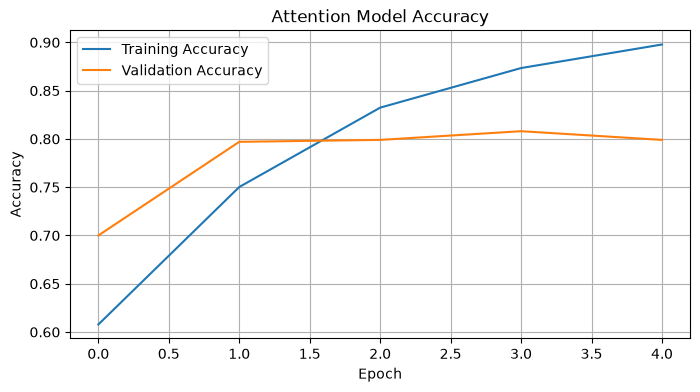

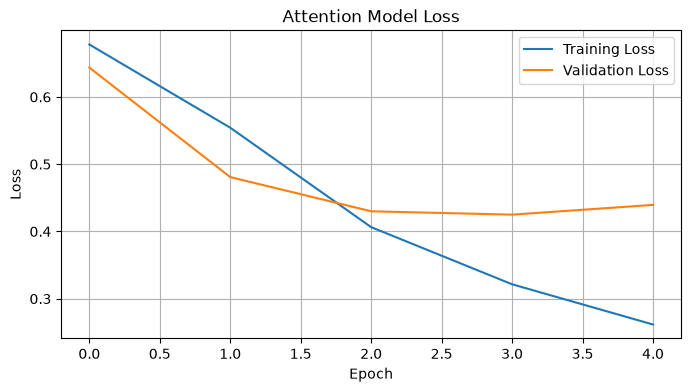



ATTENTION NLP PROJECT COMPLETED
Dataset       : IMDb Reviews
Vocabulary    : 5000
Sequence Size : 100
Model         : Self-Attention
Test Accuracy : 0.808

Saved Files:
attention_nlp_model.keras
attention_predictions.csv


In [5]:
# ============================================================
# ATTENTION MECHANISM USING NLP
# PART-3 : EVALUATION & PREDICTION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Evaluate Model
# ------------------------------------------------------------

loss, accuracy = model.evaluate(
    test_dataset,
    verbose=0
)

print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print("Test Loss     :", round(float(loss), 4))
print("Test Accuracy :", round(float(accuracy), 4))


# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

predictions = model.predict(
    X_test,
    verbose=0
).flatten()

predicted_labels = (
    predictions >= 0.5
).astype(int)


# ------------------------------------------------------------
# Prediction Results
# ------------------------------------------------------------

results = pd.DataFrame({

    "Actual": y_test.astype(int),

    "Predicted": predicted_labels,

    "Probability": np.round(
        predictions,
        3
    )

})


print("\n")
print("=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

display(
    results.head(10)
)


# ------------------------------------------------------------
# Accuracy Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Attention Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()


# ------------------------------------------------------------
# Loss Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Attention Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()


# ------------------------------------------------------------
# Save Model
# ------------------------------------------------------------

model.save(
    "attention_nlp_model.keras"
)


# ------------------------------------------------------------
# Save Predictions
# ------------------------------------------------------------

results.to_csv(
    "attention_predictions.csv",
    index=False
)


# ------------------------------------------------------------
# Final Summary
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("ATTENTION NLP PROJECT COMPLETED")
print("=" * 60)

print("Dataset       : IMDb Reviews")
print("Vocabulary    :", VOCAB_SIZE)
print("Sequence Size :", MAX_LENGTH)
print("Model         : Self-Attention")
print("Test Accuracy :", round(float(accuracy), 4))

print("\nSaved Files:")
print("attention_nlp_model.keras")
print("attention_predictions.csv")

print("=" * 60)